# Zadanie 1 -- Perceptron AND i OR
Zaimplementuj perceptron od zera i naucz go bramek logicznych AND i OR.

Wymagania:
- Klasa Perceptron z metodami fit() i predict()
- Trening na AND: (0,0)=0, (0,1)=0, (1,0)=0, (1,1)=1
- Trening na OR: (0,0)=0, (0,1)=1, (1,0)=1, (1,1)=1
- Wyświetl wagi i bias dla każdej bramki
- Zweryfikuj predykcje

Oczekiwany wynik:
- Poprawne predykcje dla AND i OR

In [10]:
# Perceptron od zera -- bramki logiczne AND i OR
import numpy as np  # biblioteka do obliczeń na macierzach i wektorach


class Perceptron:
    """Najprostszy model neuronu -- klasyfikator liniowy (przesuwa linię decyzyjną)."""

    def __init__(self, n_features, learning_rate=0.1):
        # n_features = liczba cech wejściowych (tu: 2 wejścia bramki logicznej)
        # learning_rate = jak duży krok robimy przy poprawianiu wag w każdej iteracji
        self.weights = np.random.randn(n_features) * 0.01  # wagi W -- startują blisko zera
        self.bias = 0.0  # bias b -- przesunięcie progu decyzyjnego
        self.lr = learning_rate  # zapisujemy learning rate do późniejszego użycia w fit()

    def activation(self, z):
        # z = w1*x1 + w2*x2 + ... + b  (suma ważona + bias)
        # funkcja progowa: jeśli z >= 0 --> 1, inaczej --> 0
        return np.where(z >= 0, 1, 0)

    def predict(self, X):
        """Predykcja dla wielu próbek naraz: y = step(X @ W + b)."""
        z = X @ self.weights + self.bias  # oblicz sumę ważoną dla każdego wiersza X
        return self.activation(z)  # zamień wynik liczbowy na klasę 0 lub 1

    def fit(self, X, y, n_epochs=100):
        """Trening -- reguła uczenia Rosenblatta (poprawiaj wagę tylko przy błędzie)."""
        self.errors_per_epoch = []  # lista: ile błędów było w każdej epoce

        for epoch in range(n_epochs):  # epoka = jeden pełny przejście przez wszystkie próbki
            errors = 0  # licznik błędów w tej epoce

            for xi, yi in zip(X, y):  # xi = jedna próbka wejściowa, yi = poprawna odpowiedź
                y_pred = self.activation(xi @ self.weights + self.bias)  # predykcja dla xi
                error = yi - y_pred  # błąd: 0 (trafione), 1 (powinno być 1), -1 (powinno być 0)

                # jeśli error != 0, przesuwamy granicę decyzyjną w dobrym kierunku:
                self.weights += self.lr * error * xi  # aktualizacja wag
                self.bias += self.lr * error  # aktualizacja biasu

                if error != 0:  # jeśli źle sklasyfikowano tę próbkę
                    errors += 1  # zwiększ licznik błędów w epoce

            self.errors_per_epoch.append(errors)  # zapisz wynik epoki (do analizy zbieżności)

            if errors == 0:  # jeśli w całej epoce zero błędów -- model nauczył się danych
                print(f"Konwergencja po {epoch + 1} epokach!")
                break  # early stopping -- nie ma sensu trenować dalej

        return self  # zwróć wytrenowany model (umożliwia łańcuchowanie: model.fit(...).predict(...))


def verify_gate(name, X, y, model):
    """Pomocnicza funkcja: trenuje model i sprawdza, czy predykcje są poprawne."""
    print(f"=== BRAMKA {name} ===")  # nagłówek wyniku (AND albo OR)
    model.fit(X, y)  # ucz model na danych tej bramki
    print(f"Wagi: {model.weights}, Bias: {model.bias:.3f}")  # pokaż nauczone parametry
    print("Predykcje:")
    for xi, yi in zip(X, y):  # przejdź po każdej próbce testowej
        pred = model.predict(xi.reshape(1, -1))[0]  # reshape(1,-1) bo predict oczekuje macierzy 2D
        status = "OK" if pred == yi else "BŁĄD"  # porównaj predykcję z oczekiwaną wartością
        print(f"  {xi} --> {pred} (oczekiwane: {yi}) [{status}]")
    print()  # pusta linia dla czytelności


# --- BRAMKA AND ---
# macierz X: 4 kombinacje wejść (0/1, 0/1)
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
# wektor y: oczekiwane wyjście AND (1 tylko gdy oba wejścia = 1)
y_and = np.array([0, 0, 0, 1])

perceptron_and = Perceptron(n_features=2)  # tworzymy nowy, pusty model (2 wejścia)
verify_gate("AND", X_and, y_and, perceptron_and)  # uczymy i weryfikujemy


# --- BRAMKA OR ---
# te same wejścia co wyżej, ale inna logika wyjścia
X_or = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
# OR daje 1, gdy przynajmniej jedno wejście = 1
y_or = np.array([0, 1, 1, 1])

perceptron_or = Perceptron(n_features=2)  # osobny model -- uczy się innej granicy decyzyjnej
verify_gate("OR", X_or, y_or, perceptron_or)

=== BRAMKA AND ===
Konwergencja po 4 epokach!
Wagi: [0.11389801 0.0979161 ], Bias: -0.200
Predykcje:
  [0 0] --> 0 (oczekiwane: 0) [OK]
  [0 1] --> 0 (oczekiwane: 0) [OK]
  [1 0] --> 0 (oczekiwane: 0) [OK]
  [1 1] --> 1 (oczekiwane: 1) [OK]

=== BRAMKA OR ===
Konwergencja po 5 epokach!
Wagi: [0.10860428 0.19018978], Bias: -0.100
Predykcje:
  [0 0] --> 0 (oczekiwane: 0) [OK]
  [0 1] --> 1 (oczekiwane: 1) [OK]
  [1 0] --> 1 (oczekiwane: 1) [OK]
  [1 1] --> 1 (oczekiwane: 1) [OK]



# Zadanie 2 -- Funkcje aktywacji
Zaimplementuj i zwizualizuj 4 funkcje aktywacji: sigmoid, tanh, ReLU, Leaky ReLU.

Wymagania:
- Zaimplementuj każdą funkcję i jej pochodną
- Narysuj 4 wykresy (2x2) z funkcją i pochodną na jednym
- Zakres z: od -5 do 5
- Oznacz zakres wartości na każdym wykresie

Oczekiwany wynik:
- 4 wykresy z funkcjami aktywacji i ich pochodnymi

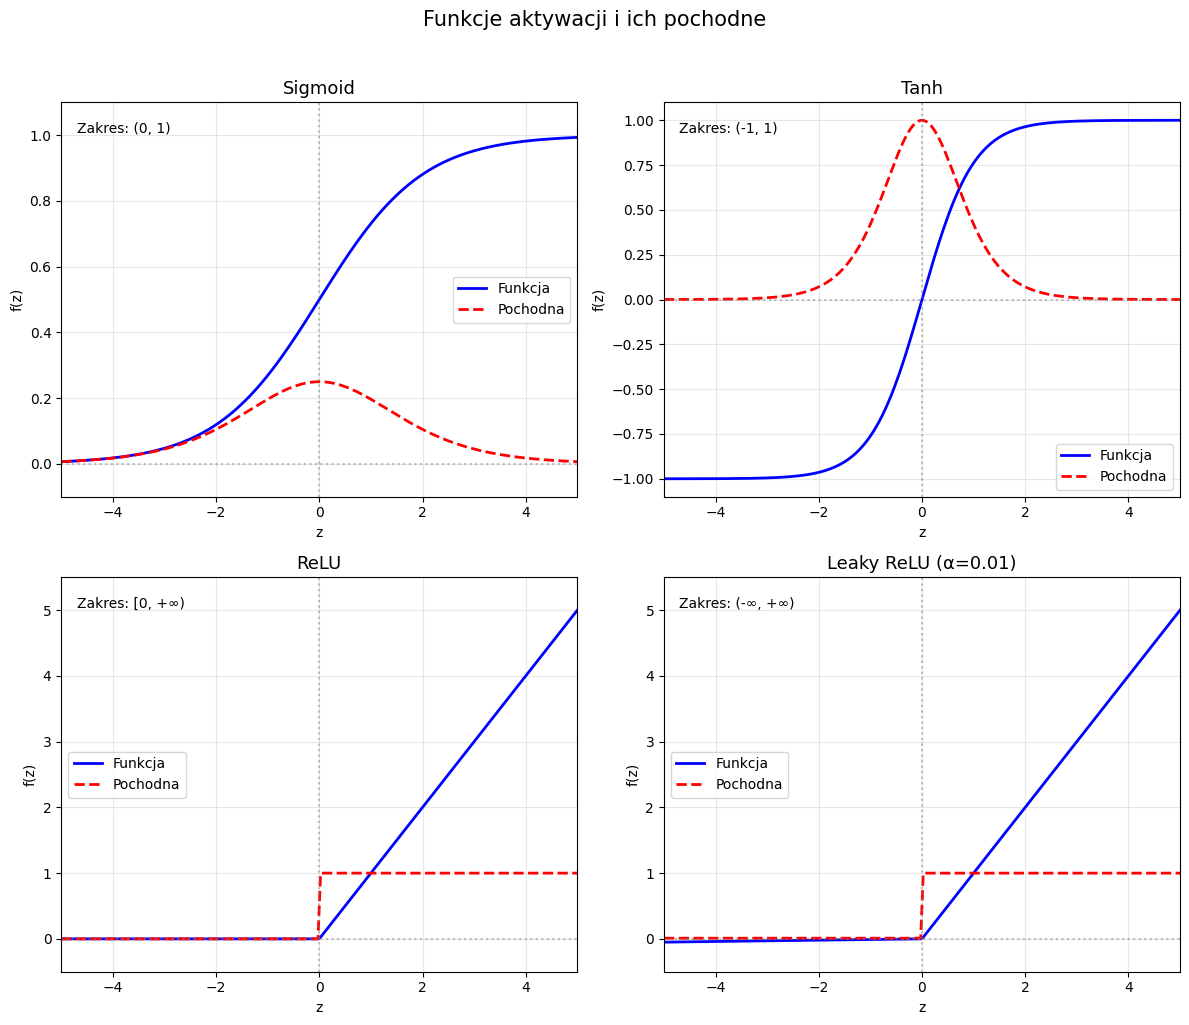

In [9]:
# Funkcje aktywacji -- implementacja, pochodne i wizualizacja
import numpy as np
import matplotlib.pyplot as plt


def sigmoid(z):
    """Sigmoid: σ(z) = 1 / (1 + e^(-z)). Zakres: (0, 1)."""
    return 1 / (1 + np.exp(-z))


def sigmoid_derivative(z):
    """Pochodna sigmoid: σ'(z) = σ(z) * (1 - σ(z))."""
    s = sigmoid(z)
    return s * (1 - s)


def tanh_fn(z):
    """Tanh: tanh(z). Zakres: (-1, 1)."""
    return np.tanh(z)


def tanh_derivative(z):
    """Pochodna tanh: 1 - tanh(z)^2."""
    return 1 - np.tanh(z) ** 2


def relu(z):
    """ReLU: max(0, z). Zakres: [0, +∞)."""
    return np.maximum(0, z)


def relu_derivative(z):
    """Pochodna ReLU: 1 dla z > 0, 0 w pozostałych przypadkach."""
    return np.where(z > 0, 1, 0)


def leaky_relu(z, alpha=0.01):
    """Leaky ReLU: z dla z > 0, alpha * z w przeciwnym razie."""
    return np.where(z > 0, z, alpha * z)


def leaky_relu_derivative(z, alpha=0.01):
    """Pochodna Leaky ReLU: 1 dla z > 0, alpha w przeciwnym razie."""
    return np.where(z > 0, 1, alpha)


# Zakres argumentu z -- wspólny dla wszystkich wykresów
z = np.linspace(-5, 5, 200)

# Układ 2x2 -- po jednym wykresie na każdą funkcję aktywacji
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Konfiguracja wykresów: (funkcja, pochodna, tytuł, zakres y, opis zakresu)
plots = [
    (sigmoid, sigmoid_derivative, "Sigmoid", (-0.1, 1.1), "Zakres: (0, 1)"),
    (tanh_fn, tanh_derivative, "Tanh", (-1.1, 1.1), "Zakres: (-1, 1)"),
    (relu, relu_derivative, "ReLU", (-0.5, 5.5), "Zakres: [0, +∞)"),
    (leaky_relu, leaky_relu_derivative, "Leaky ReLU (α=0.01)", (-0.5, 5.5), "Zakres: (-∞, +∞)"),
]

for ax, (fn, deriv, title, ylim, range_label) in zip(axes.flat, plots):
    # Niebieska linia ciągła -- funkcja aktywacji
    ax.plot(z, fn(z), "b-", linewidth=2, label="Funkcja")
    # Czerwona linia przerywana -- pochodna (potrzebna w backpropagation)
    ax.plot(z, deriv(z), "r--", linewidth=2, label="Pochodna")
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("z")
    ax.set_ylabel("f(z)")
    ax.set_xlim(-5, 5)
    ax.set_ylim(*ylim)
    # Oznaczenie zakresu wartości na wykresie (wymaganie z zadania)
    ax.text(0.03, 0.95, range_label, transform=ax.transAxes, fontsize=10, va="top")
    ax.axhline(y=0, color="gray", linestyle=":", alpha=0.5)
    ax.axvline(x=0, color="gray", linestyle=":", alpha=0.5)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Funkcje aktywacji i ich pochodne", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# Zadanie 3 -- Softmax ręcznie
Zaimplementuj funkcję softmax i przetestuj na 3 przykładach.

Wymagania:
- Implementacja softmax z numeryczną stabilnością (odejmij max)
- Test 1: z = [2.0, 1.0, 0.1]
- Test 2: z = [1.0, 1.0, 1.0] (równomierne)
- Test 3: z = [10.0, 0.0, -10.0] (dominująca klasa)
- Sprawdź, że suma prawdopodobieństw = 1.0
- Narysuj barplot dla każdego testu

Oczekiwany wynik:
- 3 barploty z rozkładami prawdopodobieństwa

=== Test 1: z = [2.0, 1.0, 0.1] ===
z: [2.  1.  0.1]
  Klasa 0: 0.659001
  Klasa 1: 0.242433
  Klasa 2: 0.098566
Suma prawdopodobieństw: 1.000000 [OK]

=== Test 2: z = [1.0, 1.0, 1.0] (równomierne) ===
z: [1. 1. 1.]
  Klasa 0: 0.333333
  Klasa 1: 0.333333
  Klasa 2: 0.333333
Suma prawdopodobieństw: 1.000000 [OK]

=== Test 3: z = [10.0, 0.0, -10.0] (dominująca klasa) ===
z: [ 10.   0. -10.]
  Klasa 0: 0.999955
  Klasa 1: 0.000045
  Klasa 2: 0.000000
Suma prawdopodobieństw: 1.000000 [OK]



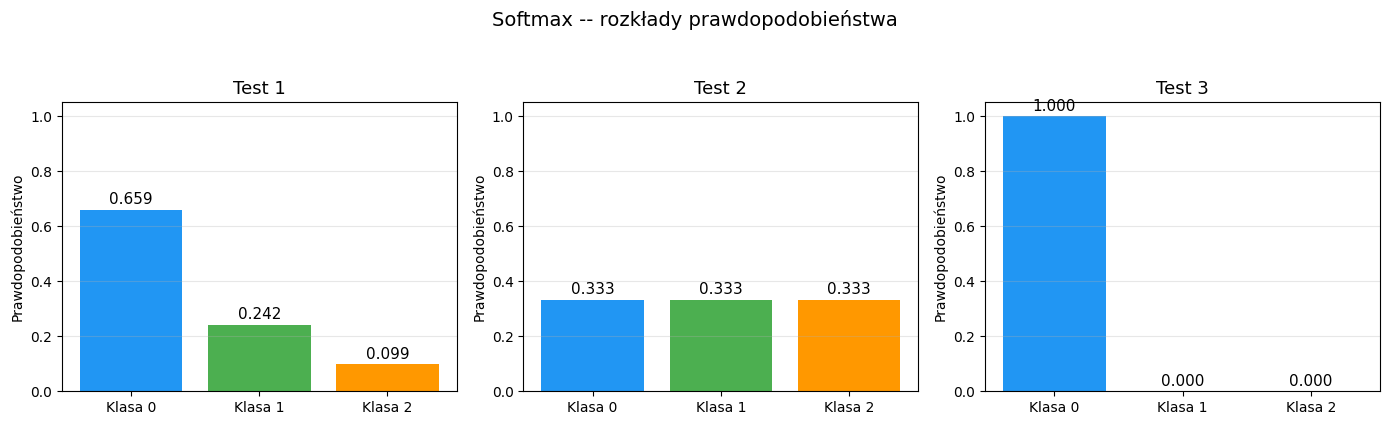

In [8]:
# Softmax od zera -- 3 testy z polecenia
import numpy as np
import matplotlib.pyplot as plt


def softmax(z):
    """Softmax: zamienia wektor logitów z na rozkład prawdopodobieństwa (suma = 1)."""
    z = np.asarray(z, dtype=float)  # upewniamy się, że pracujemy na tablicy NumPy
    # odejmujemy max(z) przed exp -- stabilność numeryczna (unikamy overflow)
    exp_z = np.exp(z - np.max(z))
    return exp_z / exp_z.sum()  # normalizacja: każda wartość / suma wszystkich


# 3 przykłady wyłącznie z treści zadania (PDF)
tests = [
    {
        "name": "Test 1",
        "desc": "z = [2.0, 1.0, 0.1]",
        "z": np.array([2.0, 1.0, 0.1]),
    },
    {
        "name": "Test 2",
        "desc": "z = [1.0, 1.0, 1.0] (równomierne)",
        "z": np.array([1.0, 1.0, 1.0]),
    },
    {
        "name": "Test 3",
        "desc": "z = [10.0, 0.0, -10.0] (dominująca klasa)",
        "z": np.array([10.0, 0.0, -10.0]),
    },
]

class_labels = ["Klasa 0", "Klasa 1", "Klasa 2"]
colors = ["#2196F3", "#4CAF50", "#FF9800"]

# 3 barploty obok siebie -- po jednym na każdy test
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, test in zip(axes, tests):
    z = test["z"]
    probs = softmax(z)  # oblicz rozkład prawdopodobieństwa dla danego wektora z

    # Weryfikacja numeryczna -- suma prawdopodobieństw musi wynosić 1.0
    print(f"=== {test['name']}: {test['desc']} ===")
    print(f"z: {z}")
    for label, p in zip(class_labels, probs):
        print(f"  {label}: {p:.6f}")
    sum_ok = np.isclose(probs.sum(), 1.0)
    print(f"Suma prawdopodobieństw: {probs.sum():.6f} [{'OK' if sum_ok else 'BŁĄD'}]")
    print()

    # Barplot rozkładu prawdopodobieństwa
    ax.bar(class_labels, probs, color=colors)
    ax.set_title(test["name"], fontsize=13)
    ax.set_ylabel("Prawdopodobieństwo")
    ax.set_ylim(0, 1.05)
    for i, p in enumerate(probs):
        ax.text(i, p + 0.02, f"{p:.3f}", ha="center", fontsize=11)
    ax.grid(True, axis="y", alpha=0.3)

plt.suptitle("Softmax -- rozkłady prawdopodobieństwa", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# Zadanie 4 -- MLPClassifier na Iris
Wytrenuj MLPClassifier na datasecie Iris.

Wymagania:
- Architektura: (10, 5), activation='relu', solver='adam'
- Standaryzacja danych (StandardScaler)
- Oblicz accuracy, wyświetl classification_report
- Narysuj krzywą uczenia (loss curve)

Oczekiwany wynik:
- Raport klasyfikacji i wykres loss

Kształt danych: (150, 4)
Klasy: ['setosa' 'versicolor' 'virginica']
Proporcje klas: [50 50 50]

Accuracy: 0.9667
Czas treningu: 0.064s
Liczba epok: 500
Architektura: 4 --> (10, 5) --> 3

Raport klasyfikacji:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



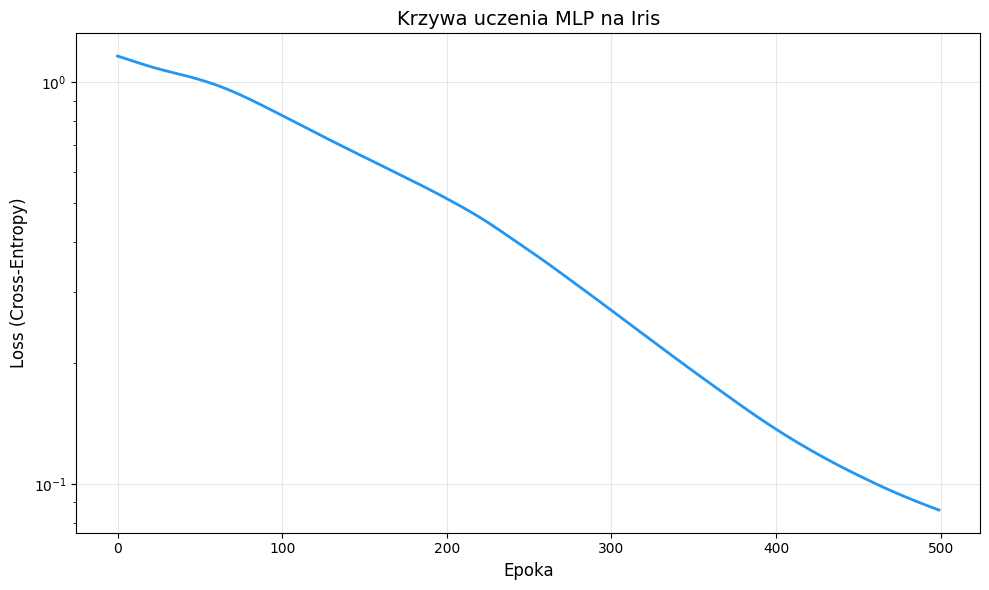

Początkowy loss: 1.1637
Końcowy loss:    0.0862


In [7]:
# MLPClassifier -- klasyfikacja Iris (sieć neuronowa sklearn)
import warnings
warnings.filterwarnings("ignore")  # wyłącza komunikaty RuntimeWarning / ConvergenceWarning sklearn

import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

# Wczytanie danych Iris (4 cechy, 3 klasy)
iris = load_iris()
X, y = iris.data, iris.target

print("Kształt danych:", X.shape)
print("Klasy:", iris.target_names)
print("Proporcje klas:", np.bincount(y))
print()

# Podział train/test 80/20 ze stratyfikacją (zachowujemy proporcje klas)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standaryzacja -- MLP wymaga cech w podobnej skali
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # uczymy skaler tylko na train
X_test_sc = scaler.transform(X_test)  # ten sam skaler stosujemy na test

# MLP: 4 wejścia --> 10 neuronów --> 5 neuronów --> 3 klasy
mlp = MLPClassifier(
    hidden_layer_sizes=(10, 5),  # 2 warstwy ukryte
    activation="relu",  # ReLU w warstwach ukrytych
    solver="adam",  # optymalizator Adam
    max_iter=500,  # maksymalna liczba epok
    random_state=42,
    early_stopping=False,  # pełny trening + pełna krzywa loss
)

start = time.time()
mlp.fit(X_train_sc, y_train)
train_time = time.time() - start

y_pred = mlp.predict(X_test_sc)
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"Czas treningu: {train_time:.3f}s")
print(f"Liczba epok: {mlp.n_iter_}")
print(f"Architektura: {X_train.shape[1]} --> {mlp.hidden_layer_sizes} --> {len(iris.target_names)}")
print()
print("Raport klasyfikacji:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Krzywa uczenia (loss curve) -- spadek błędu cross-entropy w kolejnych epokach
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(mlp.loss_curve_, linewidth=2, color="#2196F3")
ax.set_xlabel("Epoka", fontsize=12)
ax.set_ylabel("Loss (Cross-Entropy)", fontsize=12)
ax.set_title("Krzywa uczenia MLP na Iris", fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_yscale("log")  # skala log -- lepiej widać spadek loss na końcu
plt.tight_layout()
plt.show()

print(f"Początkowy loss: {mlp.loss_curve_[0]:.4f}")
print(f"Końcowy loss:    {mlp.loss_curve_[-1]:.4f}")

# Zadanie 5 -- Liczba parametrów
Napisz funkcję count_parameters() i oblicz liczbę parametrów dla 5 architektur.

Wymagania:
- Architektury: (4,3), (4,10,3), (784,128,10), (784,256,128,10), (784,512,256,128,64,10)
- Wyświetl detale: wagi + biasy per warstwa
- Narysuj barplot z całkowitą liczbą parametrów

Oczekiwany wynik:
- Tabela i wykres

=== (4, 3) ===
Architektura: 4 --> 3
-------------------------------------------------------
       4 --> 3:       12 wag +    3 biasów =       15
-------------------------------------------------------
  RAZEM:       15 parametrów

=== (4, 10, 3) ===
Architektura: 4 --> 10 --> 3
-------------------------------------------------------
      4 --> 10:       40 wag +   10 biasów =       50
      10 --> 3:       30 wag +    3 biasów =       33
-------------------------------------------------------
  RAZEM:       83 parametrów

=== (784, 128, 10) ===
Architektura: 784 --> 128 --> 10
-------------------------------------------------------
   784 --> 128:   100352 wag +  128 biasów =   100480
    128 --> 10:     1280 wag +   10 biasów =     1290
-------------------------------------------------------
  RAZEM:   101770 parametrów

=== (784, 256, 128, 10) ===
Architektura: 784 --> 256 --> 128 --> 10
-------------------------------------------------------
   784 --> 256:   200704 wag +  256 bi

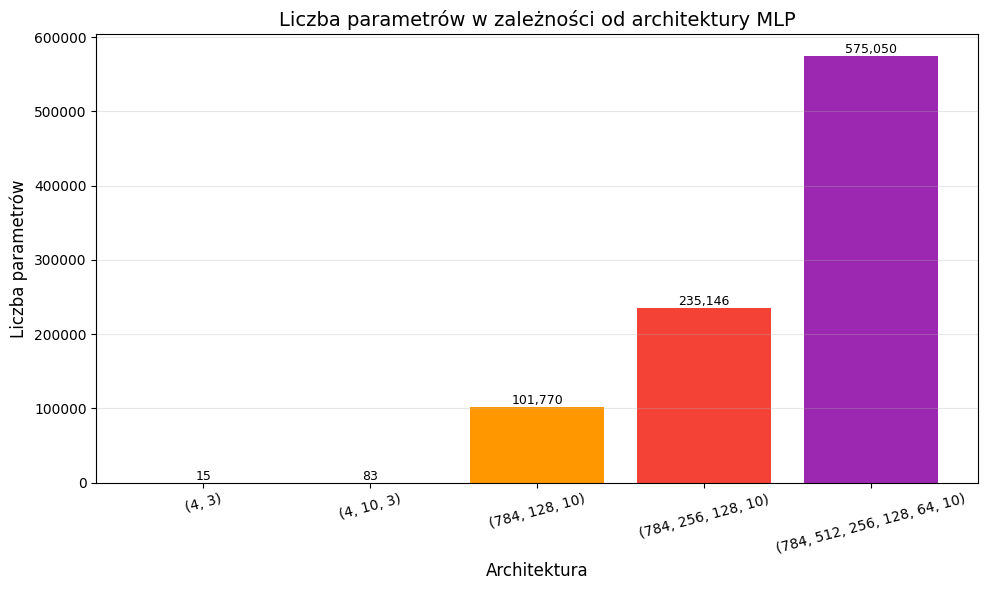

In [5]:
# Liczba parametrów w sieci neuronowej (wagi + biasy)
import matplotlib.pyplot as plt
import pandas as pd


def count_parameters(layer_sizes):
    """Oblicza liczbę parametrów (wagi + biasy) w MLP dla podanej architektury."""
    total = 0
    details = []

    # Każda para kolejnych warstw: warstwa i --> warstwa i+1
    for i in range(len(layer_sizes) - 1):
        n_weights = layer_sizes[i] * layer_sizes[i + 1]  # macierz wag
        n_biases = layer_sizes[i + 1]  # jeden bias na neuron w warstwie docelowej
        layer_total = n_weights + n_biases
        total += layer_total
        details.append({
            "warstwa": f"{layer_sizes[i]} --> {layer_sizes[i + 1]}",
            "wagi": n_weights,
            "biasy": n_biases,
            "razem": layer_total,
        })

    # Wypisanie szczegółów per warstwa
    print("Architektura:", " --> ".join(map(str, layer_sizes)))
    print("-" * 55)
    for d in details:
        print(
            f"  {d['warstwa']:>12s}: {d['wagi']:>8d} wag + "
            f"{d['biasy']:>4d} biasów = {d['razem']:>8d}"
        )
    print("-" * 55)
    print(f"  RAZEM: {total:>8d} parametrów\n")

    return total, details


# 5 architektur z polecenia (pełna ścieżka: wejście --> ukryte --> wyjście)
architectures = {
    "(4, 3)": [4, 3],
    "(4, 10, 3)": [4, 10, 3],
    "(784, 128, 10)": [784, 128, 10],
    "(784, 256, 128, 10)": [784, 256, 128, 10],
    "(784, 512, 256, 128, 64, 10)": [784, 512, 256, 128, 64, 10],
}

summary_rows = []
for name, layer_sizes in architectures.items():
    print(f"=== {name} ===")
    total, _ = count_parameters(layer_sizes)
    summary_rows.append({"Architektura": name, "Parametry": total})

# Tabela zbiorcza
summary_df = pd.DataFrame(summary_rows)
print("=== PODSUMOWANIE ===")
print(summary_df.to_string(index=False))

# Barplot — porównanie całkowitej liczby parametrów
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    summary_df["Architektura"],
    summary_df["Parametry"],
    color=["#4CAF50", "#2196F3", "#FF9800", "#F44336", "#9C27B0"],
)
ax.set_xlabel("Architektura", fontsize=12)
ax.set_ylabel("Liczba parametrów", fontsize=12)
ax.set_title("Liczba parametrów w zależności od architektury MLP", fontsize=14)
ax.tick_params(axis="x", rotation=15)
ax.grid(True, axis="y", alpha=0.3)

# Etykiety wartości na słupkach
for bar, value in zip(bars, summary_df["Parametry"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

# Zadanie 6 -- Porównanie aktywacji w MLP
Porównaj różne funkcje aktywacji w MLPClassifier na Breast Cancer.

Wymagania:
- Aktywacje: 'relu', 'tanh', 'logistic' (sigmoid)
- Architektura: (64, 32), solver='adam', max_iter=500
- Walidacja krzyżowa (cv=5)
- Narysuj bar chart z accuracy per aktywacja

Oczekiwany wynik:
- Porównanie 3 aktywacji

Kształt danych: (569, 30)
Klasy: ['malignant' 'benign']
Proporcje klas: [212 357]

      relu: CV accuracy = 0.9772 (+/- 0.0089)
      tanh: CV accuracy = 0.9666 (+/- 0.0102)
  logistic: CV accuracy = 0.9754 (+/- 0.0034)


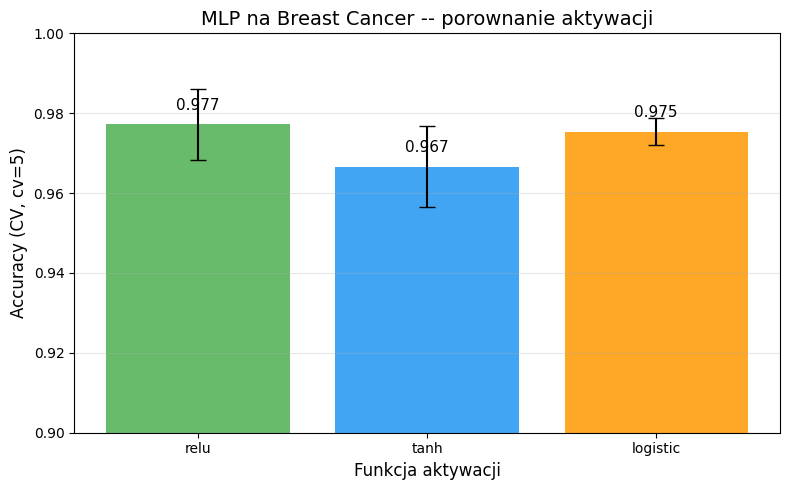


Najlepsza aktywacja: relu (CV accuracy = 0.9772)


In [4]:
# Porównanie aktywacji MLP -- Breast Cancer + walidacja krzyżowa
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

# Wczytanie danych Breast Cancer (30 cech, klasyfikacja binarna)
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

print("Kształt danych:", X.shape)
print("Klasy:", cancer.target_names)
print("Proporcje klas:", np.bincount(y))
print()

# 3 funkcje aktywacji do porownania (z polecenia)
activations = ["relu", "tanh", "logistic"]
cv_scores = {}  # srednia accuracy per aktywacja

for activation in activations:
    # Pipeline: skalowanie + MLP w jednym obiekcie (skaler uczony osobno w kazdym foldzie CV)
    model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "mlp",
            MLPClassifier(
                hidden_layer_sizes=(64, 32),
                activation=activation,
                solver="adam",
                max_iter=500,
                random_state=42,
                early_stopping=False,
            ),
        ),
    ])

    # Walidacja krzyzowa cv=5 -- 5 podzialow, srednia accuracy
    scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
    cv_scores[activation] = scores

    print(f"{activation:>10s}: CV accuracy = {scores.mean():.4f} (+/- {scores.std():.4f})")

# Bar chart -- porownanie sredniej accuracy per aktywacja
names = list(cv_scores.keys())
means = [cv_scores[a].mean() for a in names]
stds = [cv_scores[a].std() for a in names]
colors = ["#4CAF50", "#2196F3", "#FF9800"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(names, means, yerr=stds, capsize=6, color=colors, alpha=0.85)
ax.set_xlabel("Funkcja aktywacji", fontsize=12)
ax.set_ylabel("Accuracy (CV, cv=5)", fontsize=12)
ax.set_title("MLP na Breast Cancer -- porownanie aktywacji", fontsize=14)
ax.set_ylim(0.9, 1.0)
ax.grid(True, axis="y", alpha=0.3)

# Etykiety wartosci na slupkach
for bar, mean in zip(bars, means):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f"{mean:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
    )

plt.tight_layout()
plt.show()

best_activation = max(cv_scores, key=lambda a: cv_scores[a].mean())
print(f"\nNajlepsza aktywacja: {best_activation} (CV accuracy = {cv_scores[best_activation].mean():.4f})")

# Zadanie 7 -- MLPRegressor na California Housing
Wytrenuj MLPRegressor na próbce 3000 obserwacji z California Housing.

Wymagania:
- Architektura: (32, 16), early_stopping=True
- Oblicz RMSE, MAE, R2
- Narysuj wykres predykcje vs rzeczywiste
- Narysuj loss curve

Oczekiwany wynik:
- Metryki regresji i 2 wykresy

Probka: (3000, 8)

RMSE: 0.5946
MAE:  0.4225
R2:   0.7289
Epoki: 129



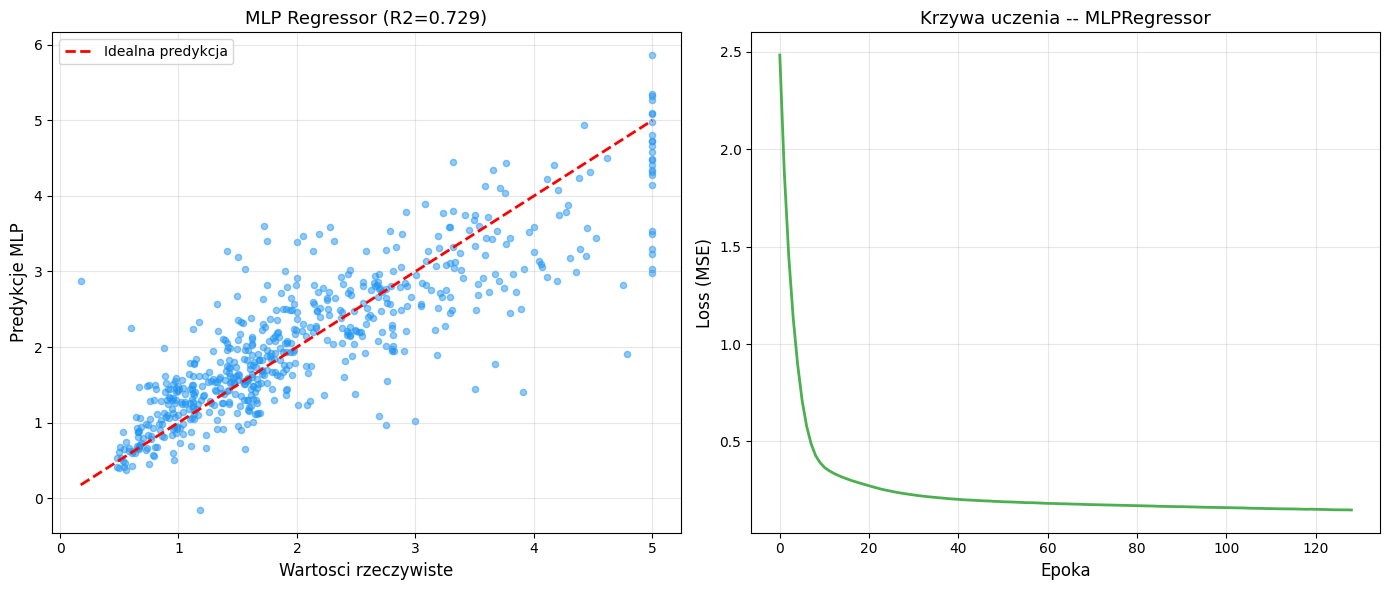

In [6]:
# MLPRegressor -- regresja na California Housing (probka 3000)
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Wczytanie California Housing (cechy demograficzne -> mediana ceny domu)
housing = fetch_california_housing()
X, y = housing.data, housing.target

# Probka 3000 obserwacji (wymaganie z zadania)
np.random.seed(42)
sample_idx = np.random.choice(len(X), size=3000, replace=False)
X_sample, y_sample = X[sample_idx], y[sample_idx]

print("Probka:", X_sample.shape)
print()

# Podzial train/test 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42
)

# Standaryzacja cech
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# MLPRegressor -- tylko parametry z polecenia: architektura + early stopping
mlp_reg = MLPRegressor(
    hidden_layer_sizes=(32, 16),
    early_stopping=True,
)

mlp_reg.fit(X_train_sc, y_train)
y_pred = mlp_reg.predict(X_test_sc)

# Metryki regresji
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R2:   {r2:.4f}")
print(f"Epoki: {mlp_reg.n_iter_}")
print()

# 2 wykresy: predykcje vs rzeczywiste + krzywa loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Wykres 1 -- predykcje vs wartosci rzeczywiste
ax1.scatter(y_test, y_pred, alpha=0.5, s=20, color="#2196F3")
ax1.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2,
    label="Idealna predykcja",
)
ax1.set_xlabel("Wartosci rzeczywiste", fontsize=12)
ax1.set_ylabel("Predykcje MLP", fontsize=12)
ax1.set_title(f"MLP Regressor (R2={r2:.3f})", fontsize=13)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Wykres 2 -- krzywa uczenia (loss curve)
ax2.plot(mlp_reg.loss_curve_, linewidth=2, color="#4CAF50")
ax2.set_xlabel("Epoka", fontsize=12)
ax2.set_ylabel("Loss (MSE)", fontsize=12)
ax2.set_title("Krzywa uczenia -- MLPRegressor", fontsize=13)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Zadanie 8 -- Early stopping
Porównaj MLP z early_stopping=True vs False na Breast Cancer.

Wymagania:
- Architektura: (64, 32), max_iter=1000
- Zmierz czas treningu i liczbę epok dla obu wariantów
- Porównaj accuracy na zbiorze testowym
- Narysuj loss curve dla obu wariantów na jednym wykresie

Oczekiwany wynik:
- Porównanie czasu, epok i accuracy

=== early_stopping=True ===
Czas treningu: 0.021s
Liczba epok:   18
Accuracy:      0.9474

=== early_stopping=False ===
Czas treningu: 0.136s
Liczba epok:   205
Accuracy:      0.9561



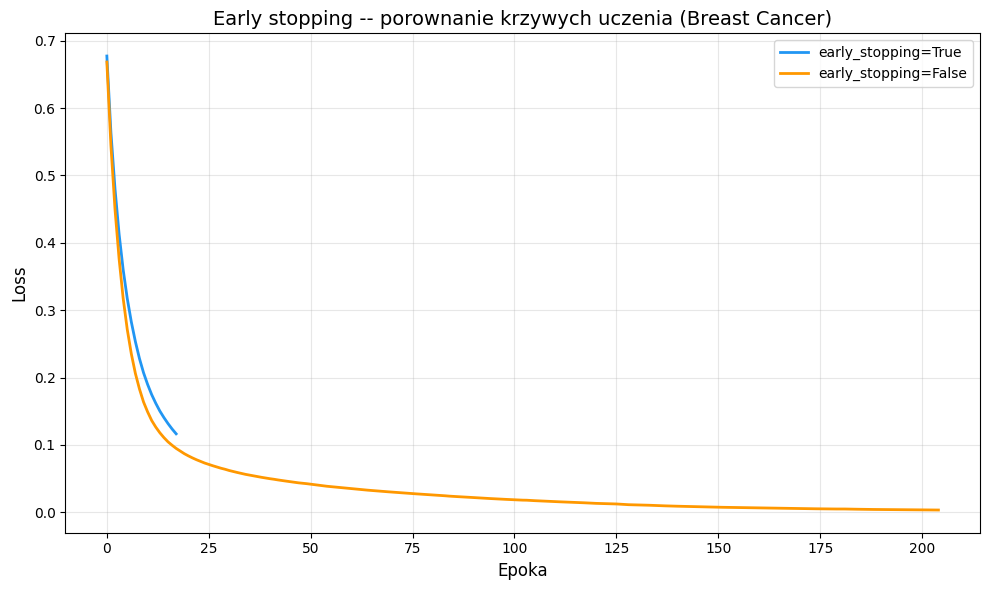

=== PODSUMOWANIE ===
   early_stopping=True: epoki=  18, czas=0.021s, accuracy=0.9474
  early_stopping=False: epoki= 205, czas=0.136s, accuracy=0.9561


In [3]:
# Early stopping -- porownanie True vs False (Breast Cancer)
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Wczytanie Breast Cancer
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# Podzial train/test 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standaryzacja
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Dwa warianty -- jedyna roznica: early_stopping
variants = {
    "early_stopping=True": True,
    "early_stopping=False": False,
}

results = {}

for label, use_early_stopping in variants.items():
    mlp = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=1000,
        early_stopping=use_early_stopping,
    )

    start = time.time()
    mlp.fit(X_train_sc, y_train)
    train_time = time.time() - start

    y_pred = mlp.predict(X_test_sc)
    acc = accuracy_score(y_test, y_pred)

    results[label] = {
        "model": mlp,
        "epochs": mlp.n_iter_,
        "time": train_time,
        "accuracy": acc,
    }

    print(f"=== {label} ===")
    print(f"Czas treningu: {train_time:.3f}s")
    print(f"Liczba epok:   {mlp.n_iter_}")
    print(f"Accuracy:      {acc:.4f}")
    print()

# Loss curve obu wariantow na jednym wykresie
fig, ax = plt.subplots(figsize=(10, 6))

colors = {"early_stopping=True": "#2196F3", "early_stopping=False": "#FF9800"}

for label, r in results.items():
    ax.plot(r["model"].loss_curve_, linewidth=2, label=label, color=colors[label])

ax.set_xlabel("Epoka", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title("Early stopping -- porownanie krzywych uczenia (Breast Cancer)", fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Podsumowanie
print("=== PODSUMOWANIE ===")
for label, r in results.items():
    print(
        f"{label:>22s}: epoki={r['epochs']:>4d}, "
        f"czas={r['time']:.3f}s, accuracy={r['accuracy']:.4f}"
    )

# Zadanie 11 -- MLP vs Random Forest na make_moons
Porównaj granice decyzyjne MLP i Random Forest na syntetycznych danych.

Wymagania:
- Wygeneruj make_moons(n_samples=500, noise=0.3)
- Wytrenuj MLP (20, 10) i Random Forest (100 drzew)
- Narysuj granice decyzyjne obu modeli obok siebie
- Porównaj accuracy, czas treningu

Oczekiwany wynik:
- 2 wykresy granic decyzyjnych i porównanie metryk

=== POROWNANIE METRYK (zbior testowy) ===
MLP (20, 10):       accuracy=0.9200, czas=0.204s
RF (10 drzew):     accuracy=0.8900, czas=0.094s



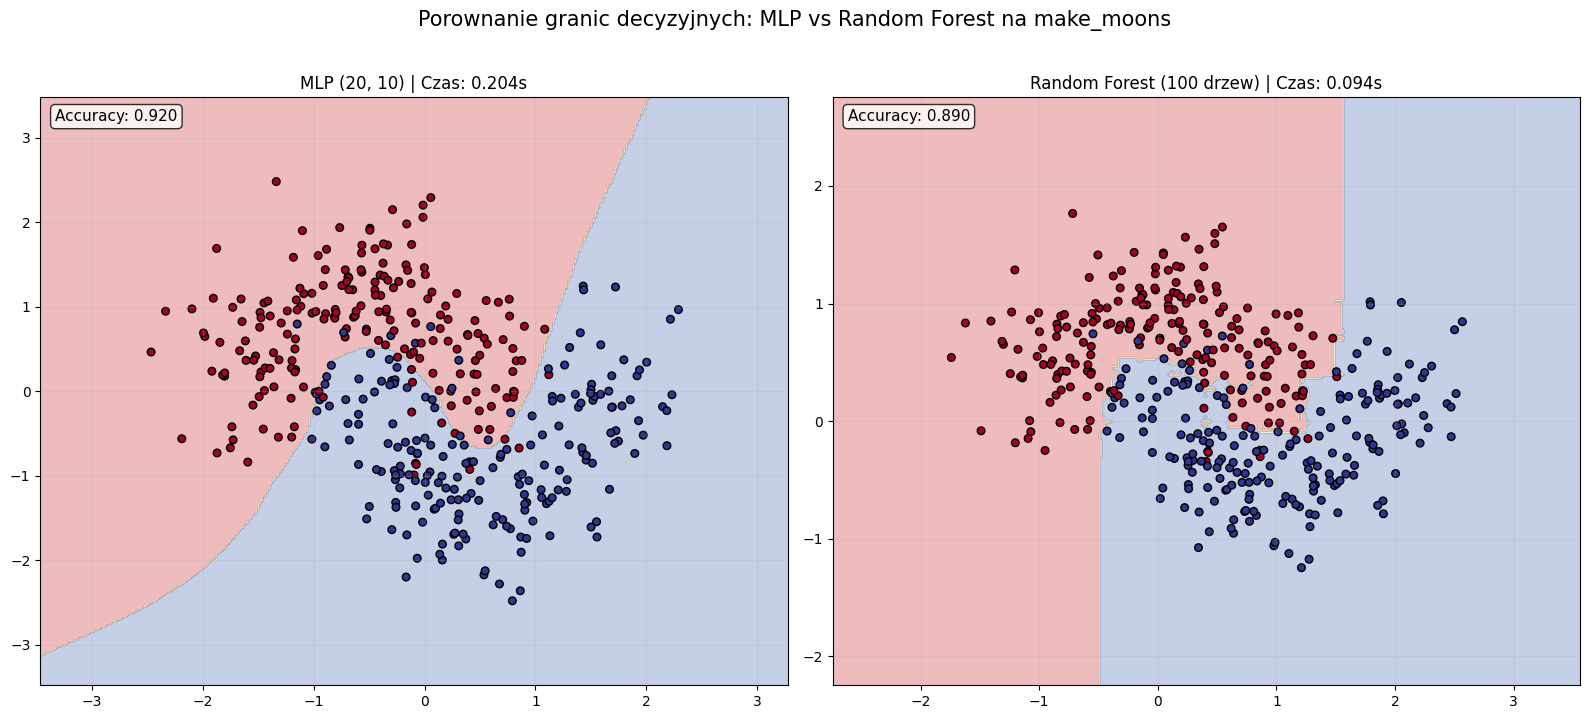

In [13]:
# Zadanie 11 -- MLP vs Random Forest na make_moons (PDF sekcja 6.1)
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Dane syntetyczne -- parametry z polecenia PDF
X, y = make_moons(n_samples=500, noise=0.3, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# MLP wymaga skalowania; RF trenujemy na surowych cechach
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# 2. Modele 
mlp = MLPClassifier(hidden_layer_sizes=(20, 10), max_iter=2000, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=8 ,n_jobs=-1)

# 3. Trening + pomiar czasu
start_mlp = time.time()
mlp.fit(X_train_sc, y_train)
time_mlp = time.time() - start_mlp

start_rf = time.time()
rf.fit(X_train, y_train)
time_rf = time.time() - start_rf

acc_mlp = accuracy_score(y_test, mlp.predict(X_test_sc))
acc_rf = accuracy_score(y_test, rf.predict(X_test))

print("=== POROWNANIE METRYK (zbior testowy) ===")
print(f"MLP (20, 10):       accuracy={acc_mlp:.4f}, czas={time_mlp:.3f}s")
print(f"RF (10 drzew):     accuracy={acc_rf:.4f}, czas={time_rf:.3f}s")
print()

# 4. Wizualizacja granic decyzyjnych 
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
h = 0.02  # gestosc siatki

# --- MLP (skalowane dane) ---
x_min, x_max = X_train_sc[:, 0].min() - 1, X_train_sc[:, 0].max() + 1
y_min, y_max = X_train_sc[:, 1].min() - 1, X_train_sc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z_mlp = mlp.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

axes[0].contourf(xx, yy, Z_mlp, alpha=0.3, cmap="RdYlBu")
axes[0].scatter(
    X_train_sc[:, 0], X_train_sc[:, 1],
    c=y_train, cmap="RdYlBu", edgecolors="black", s=30,
)
axes[0].set_title(f"MLP (20, 10) | Czas: {time_mlp:.3f}s", fontsize=12)
axes[0].grid(True, alpha=0.2)
axes[0].annotate(
    f"Accuracy: {acc_mlp:.3f}",
    xy=(0.02, 0.98), xycoords="axes fraction", va="top",
    fontsize=11, bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)

# --- Random Forest (surowe dane) ---
x_min_rf, x_max_rf = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min_rf, y_max_rf = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx_rf, yy_rf = np.meshgrid(
    np.arange(x_min_rf, x_max_rf, h), np.arange(y_min_rf, y_max_rf, h)
)

Z_rf = rf.predict(np.c_[xx_rf.ravel(), yy_rf.ravel()]).reshape(xx_rf.shape)

axes[1].contourf(xx_rf, yy_rf, Z_rf, alpha=0.3, cmap="RdYlBu")
axes[1].scatter(
    X_train[:, 0], X_train[:, 1],
    c=y_train, cmap="RdYlBu", edgecolors="black", s=30,
)
axes[1].set_title(f"Random Forest (100 drzew) | Czas: {time_rf:.3f}s", fontsize=12)
axes[1].grid(True, alpha=0.2)
axes[1].annotate(
    f"Accuracy: {acc_rf:.3f}",
    xy=(0.02, 0.98), xycoords="axes fraction", va="top",
    fontsize=11, bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)

plt.suptitle(
    "Porownanie granic decyzyjnych: MLP vs Random Forest na make_moons",
    fontsize=15, y=1.02,
)
plt.tight_layout()
plt.show()



# Zadanie dodatkowe -- Wine Quality: eksperymenty MLP vs Random Forest

Na Wine Quality przeprowadzasz **zaplanowane eksperymenty** (wartości ustalone **przed** treningiem — bez `GridSearch`):

**MLP:**
1. **Architektura** — od ekstremalnie małej do ekstremalnie dużej sieci  
2. **Learning rate** — od bardzo małego do zbyt dużego; obserwacja na **krzywych loss**

**Random Forest:**
3. **Liczba drzew** (`n_estimators`) — od małej do dużej (stała głębokość)  
4. **Głębokość** (`max_depth`) — od płytkiej do bardzo głębokiej (stała liczba drzew)

Na końcu porównujesz **MLP i RF z hiperparametrami wybranymi po eksperymentach** (najlepsze wyniki z każdego testu).

### Dataset (z lekcji 23)

| Element | Wartość |
|---------|---------|
| Plik | `winequality-red.csv` (UCI) |
| Próbka | **800 wierszy** (`random_state=42`) |
| Cechy | 11 kolumn chemicznych |
| Target | `quality >= 7` → 1 („good”) |

### Wspólne założenia MLP (jak w lekcji 24)

| Element | Wartość |
|---------|---------|
| **Funkcja straty** | **Cross-Entropy** (`MLPClassifier`, klasyfikacja binarna) |
| `solver` | `'adam'` |
| `activation` | `'relu'` |
| Skalowanie | `StandardScaler` w `Pipeline` |
| Walidacja architektur | `cross_val_score`, `cv=5` |

### Eksperyment 1 — architektury MLP (6 wariantów)

| Etykieta | `hidden_layer_sizes` | Cel |
|----------|----------------------|-----|
| bardzo mała | `(4,)` | Za mało neuronów — underfitting |
| mała | `(8,)` | Płytka sieć |
| średnia | `(32, 16)` | Punkt odniesienia (jak wcześniejsze zadania) |
| duża | `(64, 32)` | Więcej pojemności |
| bardzo duża | `(256, 128)` | Duża sieć na małym zbiorze |
| ekstremalnie duża | `(512, 256)` | Eksperymentalnie ogromna — ryzyko overfittingu |

Dla wszystkich architektur w CV: `learning_rate_init=0.001`, `early_stopping=True`.

W tabeli eks. 1: **Train accuracy** vs **CV accuracy** oraz kolumna **Train − CV** (duża luka → sygnał przeuczenia na zbiorze treningowym).

#### Architektura MLP — co to jest i jak czytać wyniki

- **`hidden_layer_sizes`** to liczba neuronów w każdej warstwie ukrytej, np. `(32, 16)` = dwie warstwy (32, potem 16 neuronów).
- Więcej neuronów i warstw → **więcej parametrów** (wagi + biasy) → sieć ma większą „pojemność”, ale na **800 próbkach** bardzo duża sieć może **przeuczyć** się bez poprawy na CV.
- W eksperymencie 1 **nie zmieniasz learning rate** — porównujesz wyłącznie **kształt sieci** przy tym samym LR (`0.001`), żeby wniosek dotyczył architektury, a nie kroku uczenia.
- **CV (5-fold)** wybiera architekturę z najwyższą średnią accuracy; **zbiór testowy** zostawiasz na finał (po dobraniu też LR i parametrów RF).
- Wykres **accuracy vs liczba parametrów** pokazuje, czy dokładanie złożoności **płaci się** lepszą accuracy, czy plateau / spadek.
- Siatka **krzywych loss** (osobny subplot na architekturę) pokazuje, czy sieć w ogóle się uczy (spadek loss) — przy zbyt małej sieci loss może spaść wolno i accuracy na CV bywa niska.

### Eksperyment 2 — learning rate (5 wartości)

**Architektura:** najlepsza z eks. 1 (CV). **Dopiero potem** lista LR testowana na tej samej sieci:

| Learning rate | Oczekiwane zachowanie na wykresie loss |
|---------------|----------------------------------------|
| `0.0001` | Bardzo wolny spadek — potrzeba wielu epok |
| `0.001` | Stabilny spadek (domyślny krok Adam) |
| `0.01` | Szybsza zbieżność |
| `0.1` | Szybciej, ale mniej stabilnie |
| `0.5` | Zbyt duży krok — loss może skakać / gorszy koniec |

Dla tego eksperymentu: `early_stopping=False`, `max_iter=500` — pełne krzywe loss do porównania.

### Eksperyment 3 — Random Forest: liczba drzew

Stała głębokość: `max_depth=10`. Lista `n_estimators` **przed** treningiem:

| `n_estimators` | Cel |
|----------------|-----|
| `10` | Mało drzew — szybciej, możliwy underfitting |
| `50` | Średnio |
| `100` | Punkt odniesienia (jak Zadanie 11) |
| `300` | Dużo drzew — wolniej, malejące korzyści |

### Eksperyment 4 — Random Forest: głębokość

Stała liczba drzew: `n_estimators=100`. Lista `max_depth` **przed** treningiem:

| `max_depth` | Cel |
|-------------|-----|
| `2` | Bardzo płytka — underfitting |
| `5` | Płytka |
| `10` | Średnia |
| `20` | Głęboka |
| `None` | Bez limitu głębokości |

### Parametry startowe (punkt odniesienia przed eksperymentami)

| Model | Parametry | Rola |
|-------|-----------|------|
| MLP | `(32, 16)`, `learning_rate_init=0.001` | Jak w wcześniejszych zadaniach — baza do porównania z 6 architekturami |
| RF | `n_estimators=100`, `max_depth=10` | Jak Zadanie 11 — baza przed eks. 3 i 4 |

**Model końcowy** w notebooku: MLP z najlepszą architekturą + LR z eks. 1–2 oraz RF z najlepszymi drzewami i głębokością z eks. 3–4.

### Wymagania (wyjście)

1. Dane + konfiguracja (listy wartości dla MLP i RF)
2. **Siatka subplotów (2×3)** — osobna krzywa loss per architektura MLP
3. **Accuracy vs parametry** — słupki CV + czerwona linia (jak na kursie)
4. **Siatka subplotów** — 5 krzywych loss dla learning rate
5. **Wykresy RF** — accuracy vs liczba drzew i vs głębokość
6. **Wykres zbiorczy** — wszystkie MLP + RF (odniesienie)
7. **Wybór najlepszych hiperparametrów** + test MLP vs RF + tabela podsumowania

### Jak obronić porównanie MLP vs RF (na prezentację)

1. **Ten sam problem:** Wine Quality, 800 wierszy, target binarny `quality >= 7`, ten sam podział train/test (`random_state=42`).
2. **Dwa osobne ścieżki strojenia:** najpierw wybieram **architekturę MLP** (eks. 1, CV), potem **learning rate** na tej architekturze (eks. 2, CV); osobno stroję RF — **liczbę drzew** (eks. 3) i **głębokość** (eks. 4), też po CV.
3. **Finał:** jeden MLP z najlepszą architekturą + LR vs jeden RF z najlepszymi `n_estimators` i `max_depth` — oba oceniam **accuracy na tym samym zbiorze testowym** (jednorazowo).
4. **Architektura:** odpowiadam na pytanie „ile neuronów/warstw wystarczy na tych danych?” — nie szukam „największej sieci”, tylko **najlepszego kompromisu** między pojemnością a generalizacją (CV + wykres parametrów).
5. **MLP vs RF** to nie wyścig losowych domyślnych modeli, tylko porównanie **dopasowanych** wersji dwóch rodzin: sieci (skalowane cechy, cross-entropy, loss curves) i lasu drzew (bez skalowania, hiperparametry drzew).
6. **Wniosek z lekcji:** na małych danych tabelarycznych RF często wygrywa lub remisuje z MLP — to oczekiwany rezultat, nie błąd w kodzie.

### Oczekiwany wniosek

- MLP: za mała sieć / zły LR → gorsze wyniki
- RF: za płytka (`max_depth=2`) → gorsza accuracy; więcej drzew nie zawsze lepiej (np. 300 ≈ 100)
- RF często ≥ MLP na danych tabelarycznych



Próbka: 800 wierszy, 11 cech
Proporcja klasy 'good' (quality >= 7): 0.140

=== KONFIGURACJA (przed treningiem) ===
Funkcja straty: cross-entropy
LR w eksperymencie architektur: 0.001
Architektura w eksperymencie LR: (32, 16)
Lista LR (MLP): [0.0001, 0.001, 0.01, 0.1, 0.5]
Lista n_estimators (RF, max_depth=10): [10, 50, 100, 300]
Lista max_depth (RF, n_estimators=100): ['2', '5', '10', '20', 'brak limitu']
RF odniesienia (test): n_estimators=100, max_depth=10
Ścieżki sieci MLP:
  bardzo mała (4,)              11 --> 4 --> 1
  mała (8,)                     11 --> 8 --> 1
  średnia (32, 16)              11 --> 32 --> 16 --> 1
  duża (64, 32)                 11 --> 64 --> 32 --> 1
  bardzo duża (256, 128)        11 --> 256 --> 128 --> 1
  ekstrem. duża (512, 256)      11 --> 512 --> 256 --> 1

bardzo mała (4,): CV=0.2000, loss 1.3558→0.2607, params=53
mała (8,): CV=0.8359, loss 0.6609→0.2422, params=105
średnia (32, 16): CV=0.8609, loss 0.8424→0.0742, params=929
duża (64, 32): CV=0.8547, l

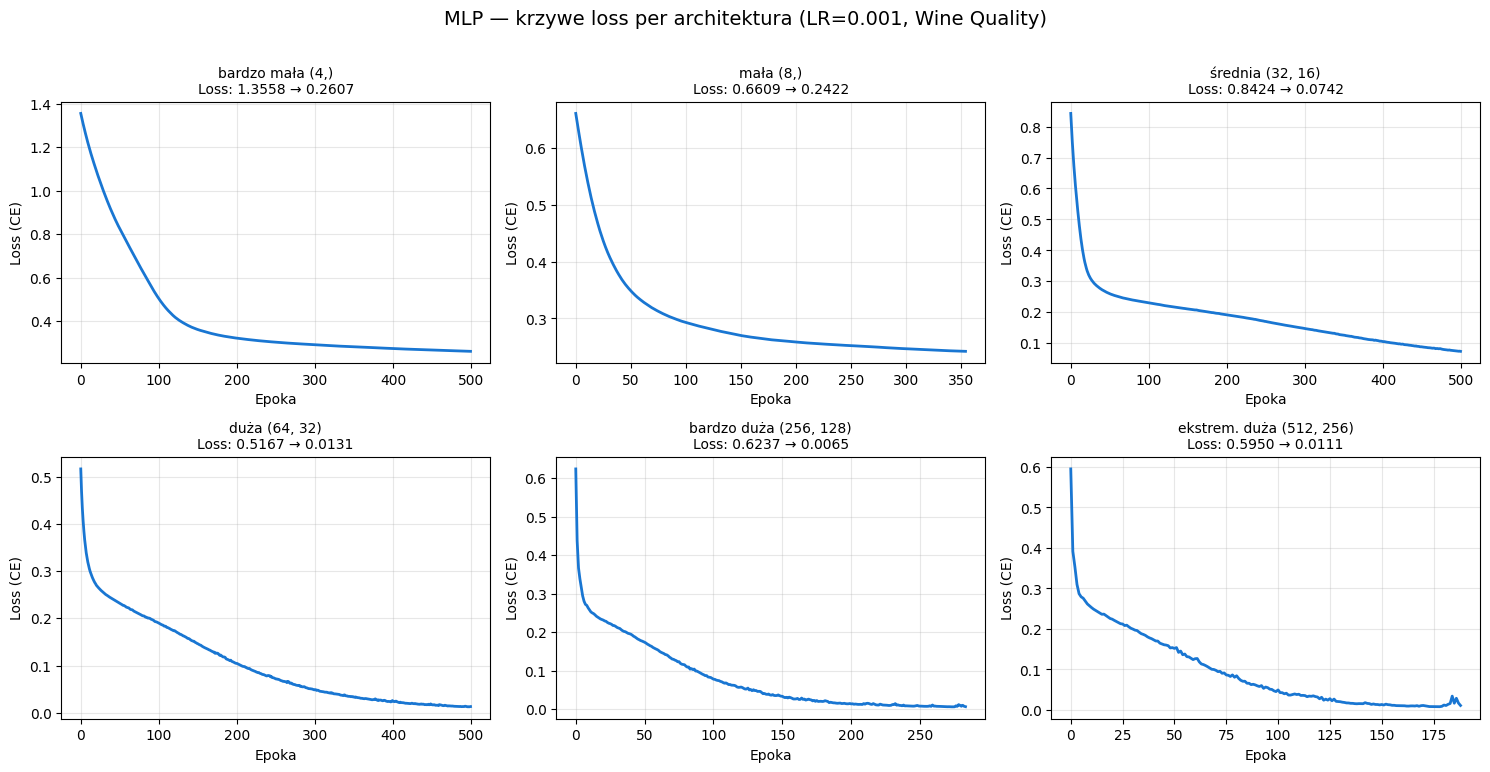

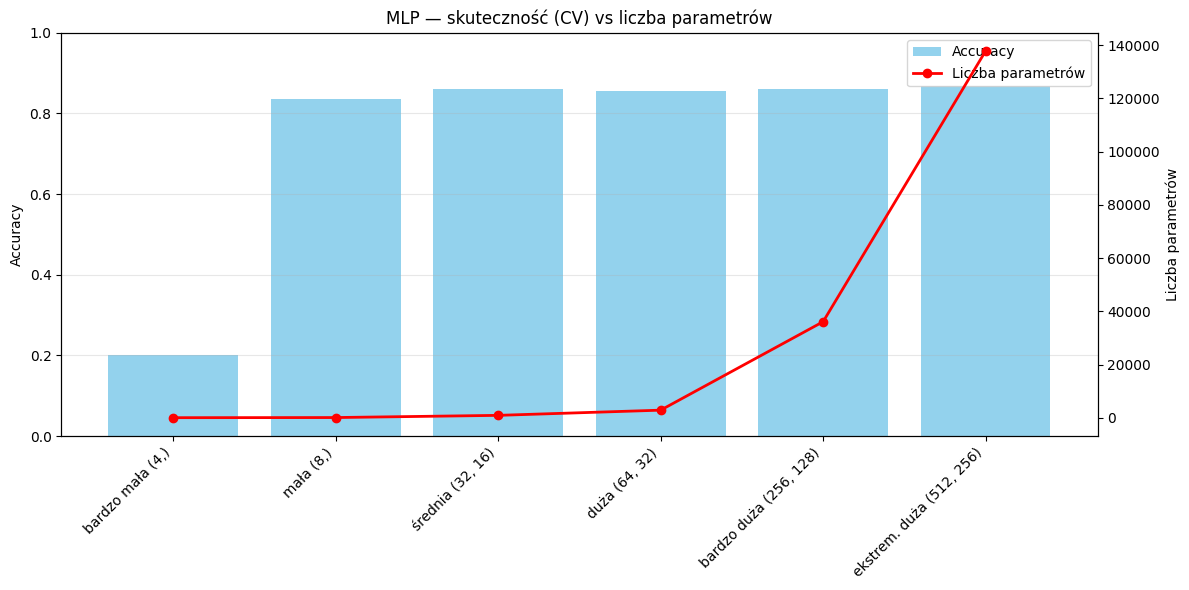

--- Interpretacja: Architektura MLP ---
  • Najlepsza w CV: ekstrem. duża (512, 256) (accuracy=0.867).
  • Najgorsza: bardzo mała (4,) (accuracy=0.200) — underfitting.
  • Wykres loss: każdy panel osobno — łatwiej porównać tempo uczenia.
  • Wykres niebieski + czerwona linia: więcej parametrów ≠ lepsza accuracy.
  • Do testu końcowego: architektura z najwyższą accuracy w CV.

LR=0.0001: test=0.8688, loss 0.8552→0.2572
LR=0.001: test=0.8938, loss 0.8424→0.0742
LR=0.01: test=0.9187, loss 0.7396→0.0420
LR=0.1: test=0.8688, loss 0.5611→0.1591
LR=0.5: test=0.8625, loss 2.2909→0.3507

=== EKSPERYMENT 2: LEARNING RATE ===
 Learning rate  Test accuracy  Końcowy loss  Epoki Ocena krzywej  Czas [s]
        0.0001         0.8688        0.2572    500       zbieżny    0.3319
        0.0010         0.8938        0.0742    500       zbieżny    0.3309
        0.0100         0.9187        0.0420    119       zbieżny    0.0792
        0.1000         0.8688        0.1591     49       zbieżny    0.0352
  

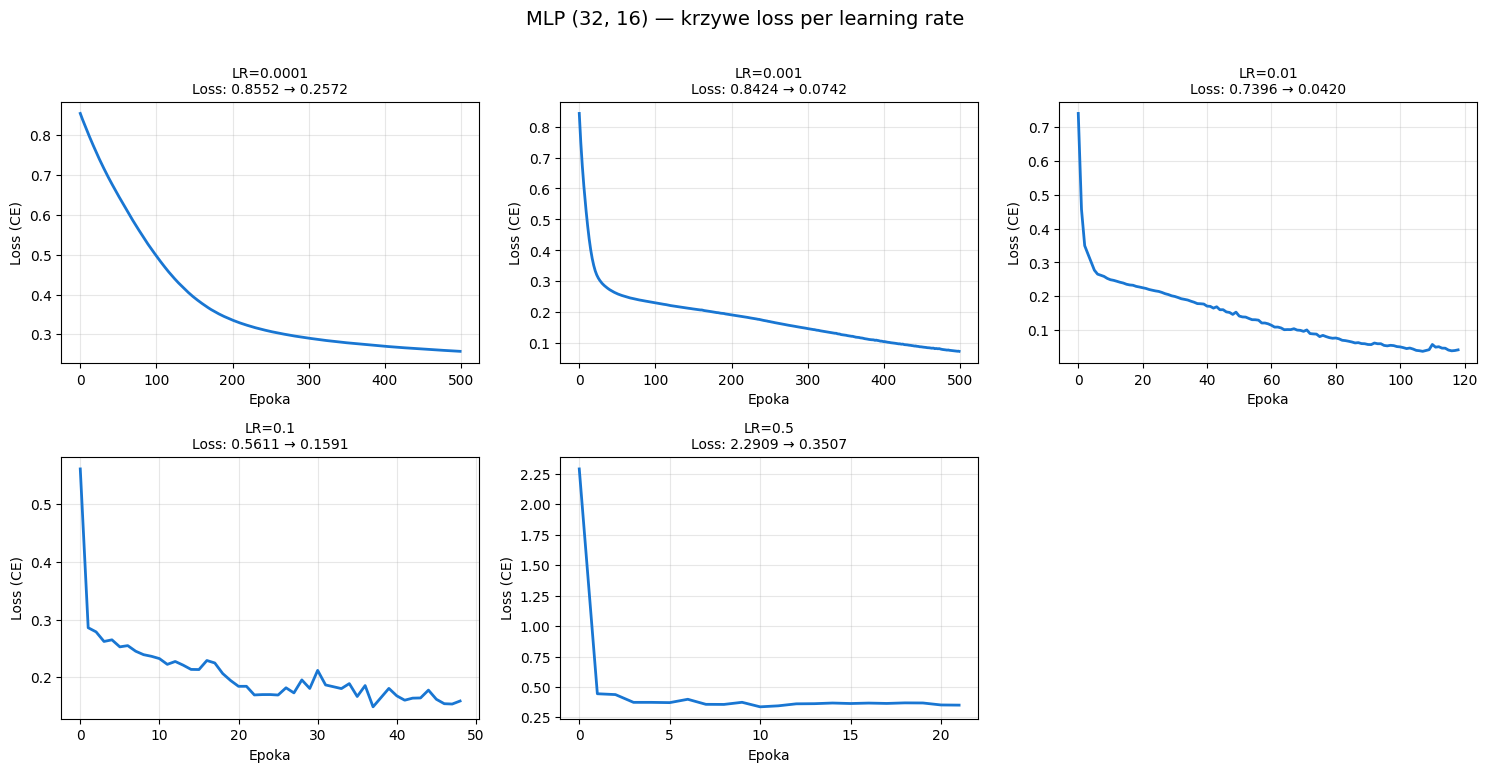

--- Interpretacja: Learning rate MLP ---
  • Najlepsza accuracy na teście: LR=0.01 (acc=0.919).
  • LR=0.0001: wolna zbieżność (500 epok).
  • LR=0.5: wyższy końcowy loss (0.3507).
  • Osobne panele loss pokazują stabilność vs szybkość uczenia.
  • Do testu końcowego: LR z najlepszą accuracy na teście.

=== EKSPERYMENT 3: RF — LICZBA DRZEW (max_depth=10) ===
 n_estimators  max_depth  CV accuracy  CV std  Czas CV [s]
           10         10       0.8719  0.0207       0.1570
           50         10       0.8766  0.0206       0.4303
          100         10       0.8797  0.0213       0.5246
          300         10       0.8703  0.0264       1.4129



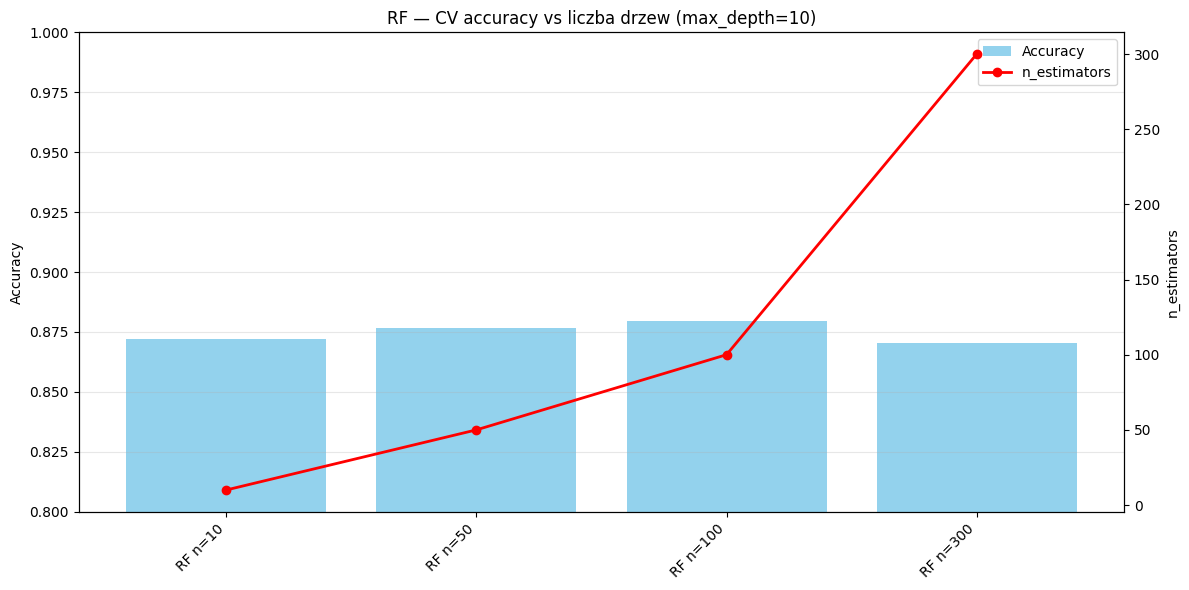

--- Interpretacja: RF — liczba drzew ---
  • Najlepsza w CV: 100 drzew (accuracy=0.880).
  • Czerwona linia = liczba drzew (złożoność modelu).
  • 300 drzew często ≈ 100, ale wolniej — malejące korzyści.
  • Odniesienie: n_estimators=100.

=== EKSPERYMENT 4: RF — GŁĘBOKOŚĆ (n=100) ===
 n_estimators   max_depth  max_depth_raw  CV accuracy  CV std  Czas CV [s]
          100           2         2.0000       0.8594  0.0000       0.5287
          100           5         5.0000       0.8750  0.0191       0.5216
          100          10        10.0000       0.8797  0.0213       0.5278
          100          20        20.0000       0.8812  0.0212       0.5527
          100 brak limitu            NaN       0.8812  0.0212       0.5219



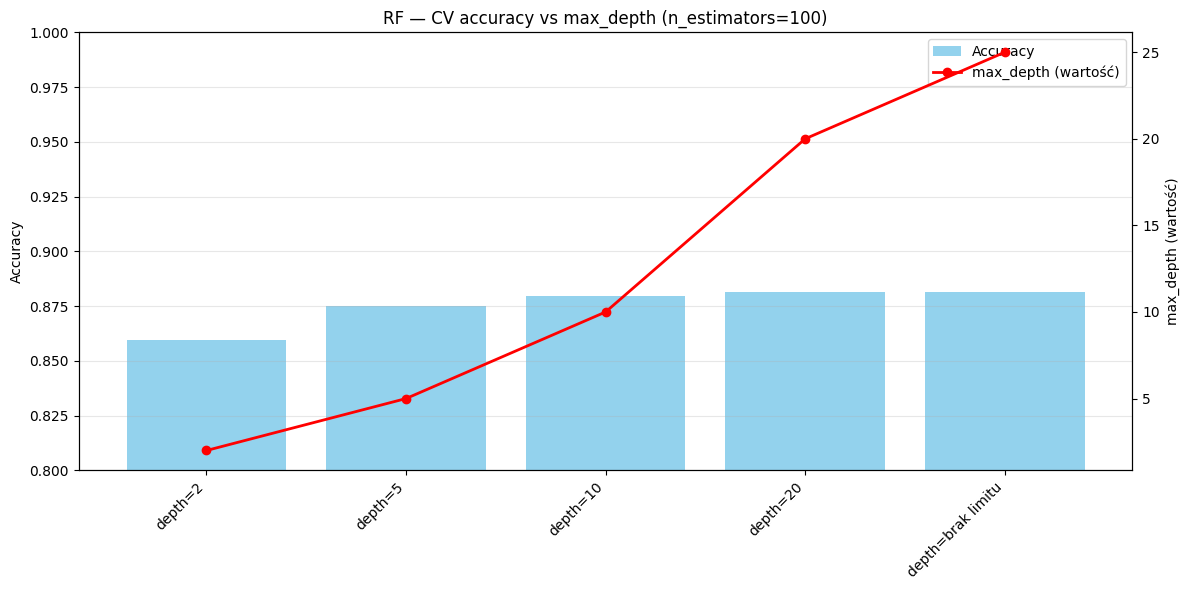

--- Interpretacja: RF — głębokość ---
  • Najlepsza w CV: max_depth=20 (accuracy=0.881).
  • Najgorsza: max_depth=2 (accuracy=0.859).
  • Czerwona linia = głębokość drzewa (im wyżej, tym bardziej złożony model).
  • Do testu końcowego: najlepsza głębokość z eksperymentu 4.

=== WYBÓR OSTATECZNYCH HIPERPARAMETRÓW ===
Funkcja straty (MLP):     cross-entropy
Architektura MLP:        (512, 256)  (ekstrem. duża (512, 256))
Learning rate MLP:       0.01
RF n_estimators:         100
RF max_depth:            20
(Punkt startowy był: MLP (32, 16), LR=0.001, RF n=100, depth=10)



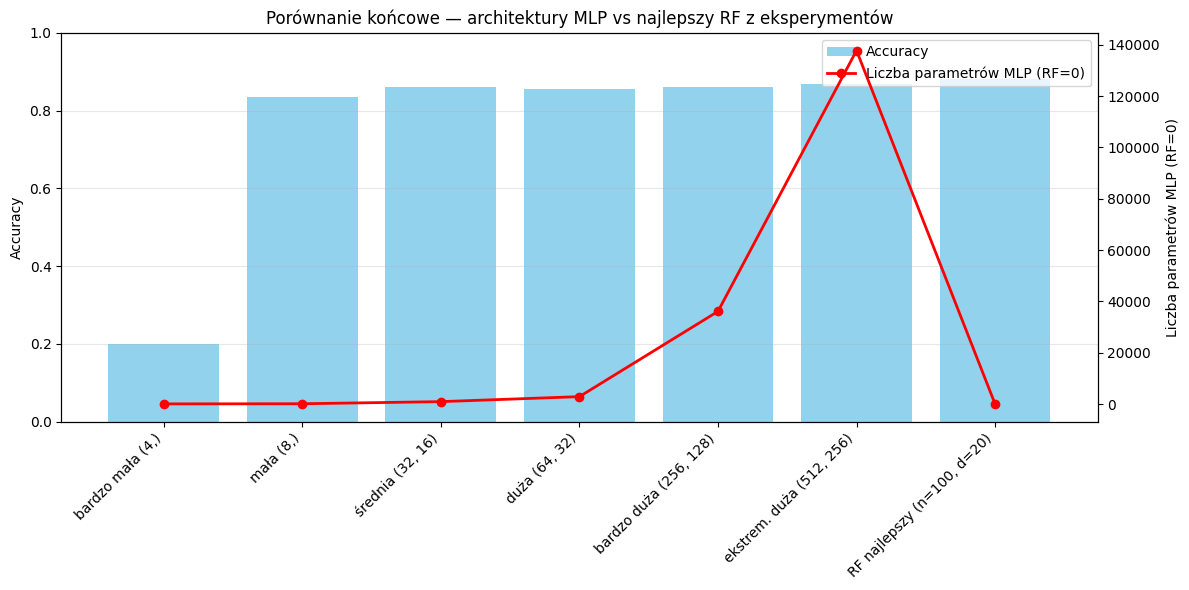

--- Interpretacja: Porównanie zbiorcze ---
  • Słupki = CV accuracy; czerwona linia = liczba parametrów MLP.
  • Najlepszy RF: n=100, max_depth=20.
  • Widać, czy większa sieć MLP przebija RF na tym zbiorze.

=== TEST: MLP vs RF (najlepsze hiperparametry z eksperymentów) ===
                  Model  Test accuracy  Czas treningu [s]
MLP (512, 256), LR=0.01         0.8625             0.1463
     RF n=100, depth=20         0.9187             0.0887

--- Interpretacja: Test końcowy MLP vs RF ---
  • MLP (512, 256), LR=0.01: test accuracy=0.863 (strata: cross-entropy).
  • RF n=100, depth=20: test accuracy=0.919.
  • Na teście wygrywa: RF.
  • Hiperparametry wybrane po eksperymentach — na podstawie CV / test accuracy.

=== PODSUMOWANIE: WYBRANE WARIANTY ===

| Parametr | Wartość w modelu końcowym | Skąd wybrano |
|----------|---------------------------|--------------|
| Funkcja straty MLP | cross-entropy | stała dla klasyfikacji binarnej |
| Architektura MLP | (512, 256) | najwyższa CV accu

In [29]:
# Wine Quality -- eksperymenty: architektura + learning rate + RF
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# --- STAŁE (ustalone przed treningiem) ---
SAMPLE_SIZE = 800
RANDOM_STATE = 42
CV_FOLDS = 5
N_FEATURES = 11
LOSS_FUNCTION = "cross-entropy"
LR_FOR_ARCH_CV = 0.001

RF_N_ESTIMATORS_LIST = [10, 50, 100, 300]
RF_MAX_DEPTH_LIST = [2, 5, 10, 20, None]
RF_DEPTH_FOR_TREES_EXP = 10
RF_TREES_FOR_DEPTH_EXP = 100
RF_REFERENCE_N = 100
RF_REFERENCE_DEPTH = 10

MLP_ARCHITECTURES = {
    "bardzo mała (4,)": (4,),
    "mała (8,)": (8,),
    "średnia (32, 16)": (32, 16),
    "duża (64, 32)": (64, 32),
    "bardzo duża (256, 128)": (256, 128),
    "ekstrem. duża (512, 256)": (512, 256),
}

LR_EXPERIMENT_ARCH = (32, 16)
LEARNING_RATES = [0.0001, 0.001, 0.01, 0.1, 0.5]
MLP_TEST_ARCH = (32, 16)   # start — finalny wybór po eksperymentach


def arch_path(hidden_layer_sizes):
    return " --> ".join([str(N_FEATURES), *[str(h) for h in hidden_layer_sizes], "1"])


def make_mlp_pipeline(
    hidden_layer_sizes,
    learning_rate_init=LR_FOR_ARCH_CV,
    early_stopping=True,
    max_iter=500,
):
    return Pipeline([
        ("scaler", StandardScaler()),
        (
            "mlp",
            MLPClassifier(
                hidden_layer_sizes=hidden_layer_sizes,
                activation="relu",
                solver="adam",
                learning_rate_init=learning_rate_init,
                max_iter=max_iter,
                random_state=RANDOM_STATE,
                early_stopping=early_stopping,
            ),
        ),
    ])


def describe_convergence(loss_curve):
    if len(loss_curve) < 2 or not np.isfinite(loss_curve[-1]):
        return "niestabilny / rozbieżny"
    if loss_curve[-1] >= loss_curve[0]:
        return "brak poprawy"
    if loss_curve[-1] < loss_curve[0] * 0.5:
        return "zbieżny"
    return "wolna zbieżność"


def depth_label(max_depth):
    return "brak limitu" if max_depth is None else str(int(max_depth))


def coerce_max_depth(max_depth):
    """sklearn wymaga int lub None — pandas czasem zwraca np.float64."""
    if max_depth is None or (isinstance(max_depth, float) and np.isnan(max_depth)):
        return None
    return int(max_depth)


def rf_cv_scores(n_estimators, max_depth):
    model = RandomForestClassifier(
        n_estimators=int(n_estimators),
        max_depth=coerce_max_depth(max_depth),
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    start = time.time()
    scores = cross_val_score(model, X_train, y_train, cv=CV_FOLDS, scoring="accuracy")
    return scores, time.time() - start


def print_chart_interpretation(title, bullets):
    print(f"--- Interpretacja: {title} ---")
    for line in bullets:
        print(f"  • {line}")
    print()


def count_mlp_params(mlp_clf):
    return sum(w.size + b.size for w, b in zip(mlp_clf.coefs_, mlp_clf.intercepts_))


def plot_loss_subplots(fitted_models, title, ncol=3):
    """Osobny panel loss na każdą konfigurację (jak u uczestnika kursu)."""
    n = len(fitted_models)
    nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5 * ncol, 3.8 * nrow))
    axes = np.atleast_1d(axes).flatten()

    for ax, (label, mlp) in zip(axes, fitted_models):
        ax.plot(mlp.loss_curve_, color="#1976D2", linewidth=2)
        ax.set_title(
            f"{label}\n"
            f"Loss: {mlp.loss_curve_[0]:.4f} → {mlp.loss_curve_[-1]:.4f}",
            fontsize=10,
        )
        ax.set_xlabel("Epoka")
        ax.set_ylabel("Loss (CE)")
        ax.grid(True, alpha=0.3)

    for ax in axes[n:]:
        ax.axis("off")

    fig.suptitle(title, fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


def plot_acc_vs_metric(df, title, metric_col, metric_label, ylim=(0.5, 1.0)):
    """Słupki = accuracy, linia = złożoność (parametry lub inna metryka)."""
    fig, ax1 = plt.subplots(figsize=(12, 6))
    x = np.arange(len(df))

    ax1.bar(x, df["Acc"], color="skyblue", alpha=0.9, label="Accuracy")
    ax1.set_ylabel("Accuracy")
    ax1.set_xticks(x)
    ax1.set_xticklabels(df["Name"], rotation=45, ha="right")
    ax1.set_ylim(ylim)
    ax1.grid(True, axis="y", alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(x, df[metric_col], color="red", marker="o", linewidth=2, label=metric_label)
    ax2.set_ylabel(metric_label)

    ax1.set_title(title)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
    plt.tight_layout()
    plt.show()


# 1. Dane
url = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "wine-quality/winequality-red.csv"
)
wine = pd.read_csv(url, sep=";")
wine["target"] = (wine["quality"] >= 7).astype(int)

wine_sample = wine.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)
X = wine_sample.drop(columns=["quality", "target"])
y = wine_sample["target"]

print(f"Próbka: {X.shape[0]} wierszy, {X.shape[1]} cech")
print(f"Proporcja klasy 'good' (quality >= 7): {y.mean():.3f}")
print()

print("=== KONFIGURACJA (przed treningiem) ===")
print(f"Funkcja straty: {LOSS_FUNCTION}")
print(f"LR w eksperymencie architektur: {LR_FOR_ARCH_CV}")
print(f"Architektura w eks. LR:     najlepsza z eks. 1 (nie {LR_EXPERIMENT_ARCH})")
print(f"Lista LR (MLP): {LEARNING_RATES}")
print(f"Lista n_estimators (RF, max_depth={RF_DEPTH_FOR_TREES_EXP}): {RF_N_ESTIMATORS_LIST}")
print(f"Lista max_depth (RF, n_estimators={RF_TREES_FOR_DEPTH_EXP}): {[depth_label(d) for d in RF_MAX_DEPTH_LIST]}")
print(f"RF odniesienia (test): n_estimators={RF_REFERENCE_N}, max_depth={RF_REFERENCE_DEPTH}")
print("Ścieżki sieci MLP:")
for name, hidden in MLP_ARCHITECTURES.items():
    print(f"  {name:28s}  {arch_path(hidden)}")
print()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# --- EKSPERYMENT 1: ARCHITEKTURA ---
arch_rows = []
arch_fitted = []
arch_compare = []

for name, hidden in MLP_ARCHITECTURES.items():
    model_cv = make_mlp_pipeline(hidden, learning_rate_init=LR_FOR_ARCH_CV, early_stopping=True)
    start = time.time()
    scores = cross_val_score(model_cv, X_train, y_train, cv=CV_FOLDS, scoring="accuracy")
    cv_elapsed = time.time() - start
    cv_mean = scores.mean()

    # Train accuracy — ten sam tryb co CV (early_stopping=True), ocena na pełnym train
    model_train = make_mlp_pipeline(hidden, learning_rate_init=LR_FOR_ARCH_CV, early_stopping=True)
    model_train.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model_train.predict(X_train))
    train_cv_gap = train_acc - cv_mean

    model_loss = make_mlp_pipeline(
        hidden, learning_rate_init=LR_FOR_ARCH_CV, early_stopping=False, max_iter=500
    )
    model_loss.fit(X_train, y_train)
    mlp = model_loss.named_steps["mlp"]

    arch_rows.append({
        "Architektura": name,
        "hidden_layer_sizes": str(hidden),
        "Train accuracy": train_acc,
        "CV accuracy": cv_mean,
        "Train − CV": train_cv_gap,
        "CV std": scores.std(),
        "Czas CV [s]": cv_elapsed,
    })
    arch_fitted.append((name, mlp))
    arch_compare.append({
        "Name": name,
        "Acc": cv_mean,
        "Params": count_mlp_params(mlp),
    })
    print(
        f"{name}: train={train_acc:.4f}, CV={cv_mean:.4f}, gap={train_cv_gap:+.4f}, "
        f"loss {mlp.loss_curve_[0]:.4f}→{mlp.loss_curve_[-1]:.4f}, "
        f"params={count_mlp_params(mlp)}"
    )

arch_table = pd.DataFrame(arch_rows)
print("\n=== EKSPERYMENT 1: ARCHITEKTURA (CV=5) ===")
print(arch_table.to_string(index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)))
print()

plot_loss_subplots(
    arch_fitted,
    f"MLP — krzywe loss per architektura (LR={LR_FOR_ARCH_CV}, Wine Quality)",
    ncol=3,
)

df_arch = pd.DataFrame(arch_compare)
plot_acc_vs_metric(
    df_arch,
    "MLP — skuteczność (CV) vs liczba parametrów",
    metric_col="Params",
    metric_label="Liczba parametrów",
    ylim=(0, 1.0),
)

best_arch_cv = arch_table.loc[arch_table["CV accuracy"].idxmax()]
worst_arch_cv = arch_table.loc[arch_table["CV accuracy"].idxmin()]
worst_gap = arch_table.loc[arch_table["Train − CV"].idxmax()]
print_chart_interpretation(
    "Architektura MLP",
    [
        f"Najlepsza w CV: {best_arch_cv['Architektura']} (CV={best_arch_cv['CV accuracy']:.3f}, train={best_arch_cv['Train accuracy']:.3f}).",
        f"Najgorsza: {worst_arch_cv['Architektura']} (CV={worst_arch_cv['CV accuracy']:.3f}) — underfitting.",
        f"Największa luka train−CV: {worst_gap['Architektura']} ({worst_gap['Train − CV']:+.3f}) — sygnał przeuczenia na train.",
        "Train i CV liczone przy early_stopping=True; loss z osobnego treningu (500 epok) tylko do wykresów.",
        "Wykres niebieski + czerwona linia: więcej parametrów ≠ lepsza CV accuracy.",
        "Ta architektura idzie do eksperymentu 2 (learning rate).",
    ],
)

# --- WYBÓR ARCHITEKTURY (zwycięzca eks. 1) → dalej tylko na niej testujemy LR ---
best_arch_name = best_arch_cv["Architektura"]
best_arch_hidden = MLP_ARCHITECTURES[best_arch_name]
print(f"\n>>> Wybrana architektura: {best_arch_hidden}  ({best_arch_name})")
print(f"    (najwyższa CV accuracy w eksperymencie 1)\n")

# --- EKSPERYMENT 2: LEARNING RATE na wybranej architekturze ---
lr_rows = []
lr_fitted = []

for lr in LEARNING_RATES:
    model_cv = make_mlp_pipeline(
        best_arch_hidden, learning_rate_init=lr, early_stopping=True
    )
    cv_scores = cross_val_score(model_cv, X_train, y_train, cv=CV_FOLDS, scoring="accuracy")

    model_loss = make_mlp_pipeline(
        best_arch_hidden, learning_rate_init=lr, early_stopping=False, max_iter=500
    )
    start = time.time()
    model_loss.fit(X_train, y_train)
    elapsed = time.time() - start
    mlp = model_loss.named_steps["mlp"]
    test_acc = accuracy_score(y_test, model_loss.predict(X_test))
    status = describe_convergence(mlp.loss_curve_)

    lr_rows.append({
        "Learning rate": lr,
        "CV accuracy": cv_scores.mean(),
        "CV std": cv_scores.std(),
        "Test accuracy": test_acc,
        "Końcowy loss": mlp.loss_curve_[-1],
        "Epoki": mlp.n_iter_,
        "Ocena krzywej": status,
        "Czas [s]": elapsed,
    })
    lr_fitted.append((f"LR={lr}", mlp))
    print(
        f"LR={lr}: CV={cv_scores.mean():.4f}, test={test_acc:.4f}, "
        f"loss {mlp.loss_curve_[0]:.4f}→{mlp.loss_curve_[-1]:.4f}"
    )

lr_table = pd.DataFrame(lr_rows)
print(f"\n=== EKSPERYMENT 2: LEARNING RATE (architektura {best_arch_hidden}) ===")
print(lr_table.to_string(index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)))
print()

plot_loss_subplots(
    lr_fitted,
    f"MLP {best_arch_hidden} — krzywe loss per learning rate",
    ncol=3,
)

best_lr = lr_table.loc[lr_table["CV accuracy"].idxmax()]
worst_lr_loss = lr_table.loc[lr_table["Końcowy loss"].idxmax()]
slow_lr = lr_table.loc[lr_table["Learning rate"] == 0.0001].iloc[0]
best_lr_val = float(best_lr["Learning rate"])

print(f">>> Wybrany learning rate: {best_lr_val}  (najwyższa CV accuracy w eks. 2)\n")

print_chart_interpretation(
    "Learning rate MLP",
    [
        f"LR testowany na tej samej architekturze co zwycięzca eks. 1: {best_arch_hidden}.",
        f"Najlepszy LR w CV: {best_lr_val} (CV={best_lr['CV accuracy']:.3f}, test={best_lr['Test accuracy']:.3f}).",
        f"LR=0.0001: wolna zbieżność ({int(slow_lr['Epoki'])} epok).",
        f"LR={worst_lr_loss['Learning rate']}: wyższy końcowy loss ({worst_lr_loss['Końcowy loss']:.4f}).",
        "Finał MLP = ta architektura + ten LR — spójna para hiperparametrów.",
    ],
)

# --- EKSPERYMENT 3: RF — liczba drzew ---
trees_rows = []
trees_compare = []

for n_trees in RF_N_ESTIMATORS_LIST:
    scores, elapsed = rf_cv_scores(n_trees, RF_DEPTH_FOR_TREES_EXP)
    trees_rows.append({
        "n_estimators": n_trees,
        "max_depth": RF_DEPTH_FOR_TREES_EXP,
        "CV accuracy": scores.mean(),
        "CV std": scores.std(),
        "Czas CV [s]": elapsed,
    })
    trees_compare.append({
        "Name": f"RF n={n_trees}",
        "Acc": scores.mean(),
        "Params": n_trees,
    })

trees_table = pd.DataFrame(trees_rows)
print(f"=== EKSPERYMENT 3: RF — LICZBA DRZEW (max_depth={RF_DEPTH_FOR_TREES_EXP}) ===")
print(trees_table.to_string(index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)))
print()

plot_acc_vs_metric(
    pd.DataFrame(trees_compare),
    f"RF — CV accuracy vs liczba drzew (max_depth={RF_DEPTH_FOR_TREES_EXP})",
    metric_col="Params",
    metric_label="n_estimators",
    ylim=(0.8, 1.0),
)

best_trees = trees_table.loc[trees_table["CV accuracy"].idxmax()]
print_chart_interpretation(
    "RF — liczba drzew",
    [
        f"Najlepsza w CV: {int(best_trees['n_estimators'])} drzew (accuracy={best_trees['CV accuracy']:.3f}).",
        "Czerwona linia = liczba drzew (złożoność modelu).",
        "300 drzew często ≈ 100, ale wolniej — malejące korzyści.",
        f"Odniesienie: n_estimators={RF_REFERENCE_N}.",
    ],
)

# --- EKSPERYMENT 4: RF — głębokość ---
depth_rows = []
depth_compare = []

for depth in RF_MAX_DEPTH_LIST:
    scores, elapsed = rf_cv_scores(RF_TREES_FOR_DEPTH_EXP, depth)
    depth_val = 25 if depth is None else depth
    depth_rows.append({
        "n_estimators": RF_TREES_FOR_DEPTH_EXP,
        "max_depth": depth_label(depth),
        "max_depth_raw": depth,
        "CV accuracy": scores.mean(),
        "CV std": scores.std(),
        "Czas CV [s]": elapsed,
    })
    depth_compare.append({
        "Name": f"depth={depth_label(depth)}",
        "Acc": scores.mean(),
        "Params": depth_val,
    })

depth_table = pd.DataFrame(depth_rows)
print(f"=== EKSPERYMENT 4: RF — GŁĘBOKOŚĆ (n={RF_TREES_FOR_DEPTH_EXP}) ===")
print(depth_table.to_string(index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)))
print()

plot_acc_vs_metric(
    pd.DataFrame(depth_compare),
    f"RF — CV accuracy vs max_depth (n_estimators={RF_TREES_FOR_DEPTH_EXP})",
    metric_col="Params",
    metric_label="max_depth (wartość)",
    ylim=(0.8, 1.0),
)

best_depth = depth_table.loc[depth_table["CV accuracy"].idxmax()]
worst_depth = depth_table.loc[depth_table["CV accuracy"].idxmin()]
print_chart_interpretation(
    "RF — głębokość",
    [
        f"Najlepsza w CV: max_depth={best_depth['max_depth']} (accuracy={best_depth['CV accuracy']:.3f}).",
        f"Najgorsza: max_depth={worst_depth['max_depth']} (accuracy={worst_depth['CV accuracy']:.3f}).",
        "Czerwona linia = głębokość drzewa (im wyżej, tym bardziej złożony model).",
        "Do testu końcowego: najlepsza głębokość z eksperymentu 4.",
    ],
)

# --- WYBÓR OSTATECZNYCH PARAMETRÓW (MLP już spójne z eks. 1 + 2) ---
best_rf_n = int(best_trees["n_estimators"])
best_depth_idx = depth_table["CV accuracy"].idxmax()
if "max_depth_raw" in depth_table.columns:
    best_rf_depth_raw = depth_table.loc[best_depth_idx, "max_depth_raw"]
else:
    # fallback: ta sama kolejność co RF_MAX_DEPTH_LIST w eksperymencie 4
    best_rf_depth_raw = RF_MAX_DEPTH_LIST[depth_table.index.get_loc(best_depth_idx)]

print("=== WYBÓR OSTATECZNYCH HIPERPARAMETRÓW ===")
print(f"Funkcja straty (MLP):     {LOSS_FUNCTION}")
print(f"Architektura MLP:        {best_arch_hidden}  ({best_arch_name})")
print(f"Learning rate MLP:       {best_lr_val}")
print(f"RF n_estimators:         {best_rf_n}")
print(f"RF max_depth:            {depth_label(best_rf_depth_raw)}")
print(
    f"(Punkt startowy był: MLP {MLP_TEST_ARCH}, LR=0.001, "
    f"RF n={RF_REFERENCE_N}, depth={RF_REFERENCE_DEPTH})"
)
print()

# --- PORÓWNANIE KOŃCOWE: wszystkie MLP + najlepszy RF (CV) ---
rf_best_scores, _ = rf_cv_scores(best_rf_n, best_rf_depth_raw)

summary_compare = arch_compare + [
    {
        "Name": f"RF najlepszy (n={best_rf_n}, d={depth_label(best_rf_depth_raw)})",
        "Acc": rf_best_scores.mean(),
        "Params": 0,
    }
]

df_summary = pd.DataFrame(summary_compare)
plot_acc_vs_metric(
    df_summary,
    "Porównanie końcowe — architektury MLP vs najlepszy RF z eksperymentów",
    metric_col="Params",
    metric_label="Liczba parametrów MLP (RF=0)",
    ylim=(0, 1.0),
)

print_chart_interpretation(
    "Porównanie zbiorcze",
    [
        "Słupki = CV accuracy; czerwona linia = liczba parametrów MLP.",
        f"Najlepszy RF: n={best_rf_n}, max_depth={depth_label(best_rf_depth_raw)}.",
        "Widać, czy większa sieć MLP przebija RF na tym zbiorze.",
    ],
)

# --- TEST końcowy: MLP i RF z najlepszymi hiperparametrami ---
mlp_final = make_mlp_pipeline(
    best_arch_hidden,
    learning_rate_init=best_lr_val,
    early_stopping=True,
)
start = time.time()
mlp_final.fit(X_train, y_train)
mlp_time = time.time() - start
mlp_test_acc = accuracy_score(y_test, mlp_final.predict(X_test))

rf_final = RandomForestClassifier(
    n_estimators=int(best_rf_n),
    max_depth=coerce_max_depth(best_rf_depth_raw),
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
start = time.time()
rf_final.fit(X_train, y_train)
rf_time = time.time() - start
rf_test_acc = accuracy_score(y_test, rf_final.predict(X_test))

mlp_final_label = f"MLP {best_arch_hidden}, LR={best_lr_val}"
rf_final_label = f"RF n={best_rf_n}, depth={depth_label(best_rf_depth_raw)}"

test_table = pd.DataFrame({
    "Model": [mlp_final_label, rf_final_label],
    "Test accuracy": [mlp_test_acc, rf_test_acc],
    "Czas treningu [s]": [mlp_time, rf_time],
})

print("=== TEST: MLP vs RF (najlepsze hiperparametry z eksperymentów) ===")
print(test_table.to_string(index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)))
print()

if mlp_test_acc > rf_test_acc:
    winner = "MLP"
elif rf_test_acc > mlp_test_acc:
    winner = "RF"
else:
    winner = "remis"

print_chart_interpretation(
    "Test końcowy MLP vs RF",
    [
        f"{mlp_final_label}: test accuracy={mlp_test_acc:.3f} (strata: {LOSS_FUNCTION}).",
        f"{rf_final_label}: test accuracy={rf_test_acc:.3f}.",
        f"Na teście wygrywa: {winner}.",
        "Hiperparametry wybrane po eksperymentach — na podstawie CV / test accuracy.",
    ],
)

print("=== PODSUMOWANIE: WYBRANE WARIANTY ===")
print()
print("| Parametr | Wartość w modelu końcowym | Skąd wybrano |")
print("|----------|---------------------------|--------------|")
print(f"| Funkcja straty MLP | {LOSS_FUNCTION} | stała dla klasyfikacji binarnej |")
print(f"| Architektura MLP | {best_arch_hidden} | najwyższa CV accuracy (eks. 1) |")
print(f"| Learning rate MLP | {best_lr_val} | najwyższa CV na arch. z eks. 1 (eks. 2) |")
print(f"| RF n_estimators | {best_rf_n} | najwyższa CV accuracy (eks. 3) |")
print(f"| RF max_depth | {depth_label(best_rf_depth_raw)} | najwyższa CV accuracy (eks. 4) |")
print()
print("Uzasadnienie:")
print("  • MLP: najpierw architektura (CV, eks. 1), potem LR na TEJ architekturze (CV, eks. 2).")
print("  • RF: osobno drzewa i głębokość (CV) — nie mieszamy z MLP.")
print(f"  • Punkt startowy MLP był {MLP_TEST_ARCH}, LR=0.001 — eksperymenty mogły wybrać inaczej.")
print()
print("=== WNIOSKI OGÓLNE ===")
print("  • MLP (4,): underfitting; duża sieć = niższy loss, nie zawsze lepsza accuracy.")
print("  • MLP: LR za mały = wolno; za duży = gorszy końcowy loss.")
print("  • RF: za płytka sieć drzew słabsza; więcej drzew ≠ zawsze lepiej od 100.")
print("  • Tabular: często RF ≥ MLP — po doborze hiperparametrów warto porównać oba.")
